Test accuracy: 0.9715


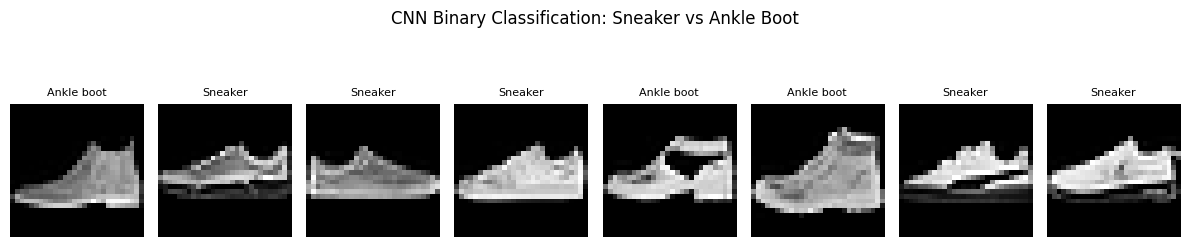

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion-MNIST data
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Select two classes only:
# 7 = Sneaker, 9 = Ankle boot
selected_classes = [7, 9]

train_filter = np.isin(train_labels, selected_classes)
test_filter = np.isin(test_labels, selected_classes)

# Keep selected images and normalize them
x_train = train_images[train_filter].astype("float32") / 255.0
x_test = test_images[test_filter].astype("float32") / 255.0

# Convert labels to binary values
# Sneaker = 0, Ankle boot = 1
y_train = (train_labels[train_filter] == 9).astype("float32")
y_test = (test_labels[test_filter] == 9).astype("float32")

# Add channel dimension for CNN input
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Build CNN model
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = cnn_model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    verbose=0
)

# Evaluate the model
loss_value, accuracy_value = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {accuracy_value:.4f}")

# Show some predictions
sample_images = x_test[:8]
prediction_scores = cnn_model.predict(sample_images, verbose=0)
predicted_labels = (prediction_scores > 0.5).astype("int32").flatten()

class_names = ["Sneaker", "Ankle boot"]

plt.figure(figsize=(12, 3))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(class_names[predicted_labels[i]], fontsize=8)
    plt.axis("off")

plt.suptitle("CNN Binary Classification: Sneaker vs Ankle Boot")
plt.tight_layout()
plt.show()